In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import multivariate_normal

In [2]:
data = pd.read_excel("data/songlist.xlsx")

## 1. Data review

In [3]:
data

,name,artist,danceability,energy,loudness,acousticness,liveness,valence,tempo,popularity,duration_sec,genre
0,A Crisis Of Revelation,Trivium,27.1,97.8,-4.005,0.000729,13.80,34.70,106.042,53.0,335.792,metal
1,A Grey so Dark,Trivium,45.1,89.6,-3.396,0.058000,32.30,78.00,83.898,37.0,161.333,metal
2,A Gunshot to the Head of Trepidation,Trivium,25.4,95.2,-3.472,0.002680,20.90,48.10,145.024,46.0,355.320,metal
3,A Skyline's Severance,Trivium,18.7,97.3,-4.322,0.002840,31.20,36.00,185.035,39.0,292.160,metal
4,A View of Burning Empires,Trivium,23.9,38.8,-10.314,2.850000,53.40,8.99,142.567,24.0,109.907,metal
...,...,...,...,...,...,...,...,...,...,...,...,...
3085,rockstar,Post Malone,59.4,50.7,-6.141,14.500000,13.20,13.70,159.729,55.0,218.147,pop
3086,Staring At The Sun (feat. SZA),Post Malone,72.4,77.2,-4.389,25.000000,30.80,34.70,95.074,70.0,168.280,pop
3087,Stay,Post Malone,50.7,48.0,-5.418,44.900000,14.70,35.00,86.046,76.0,204.427,pop
3088,Take What You Want (feat. Ozzy Osbourne & Trav...,Post Malone,49.9,80.0,-2.665,9.060000,14.70,27.20,139.919,77.0,229.573,pop


In [4]:
data.groupby(["genre"]).size()

genre
metal    1253
pop      1377
rock      460
dtype: int64

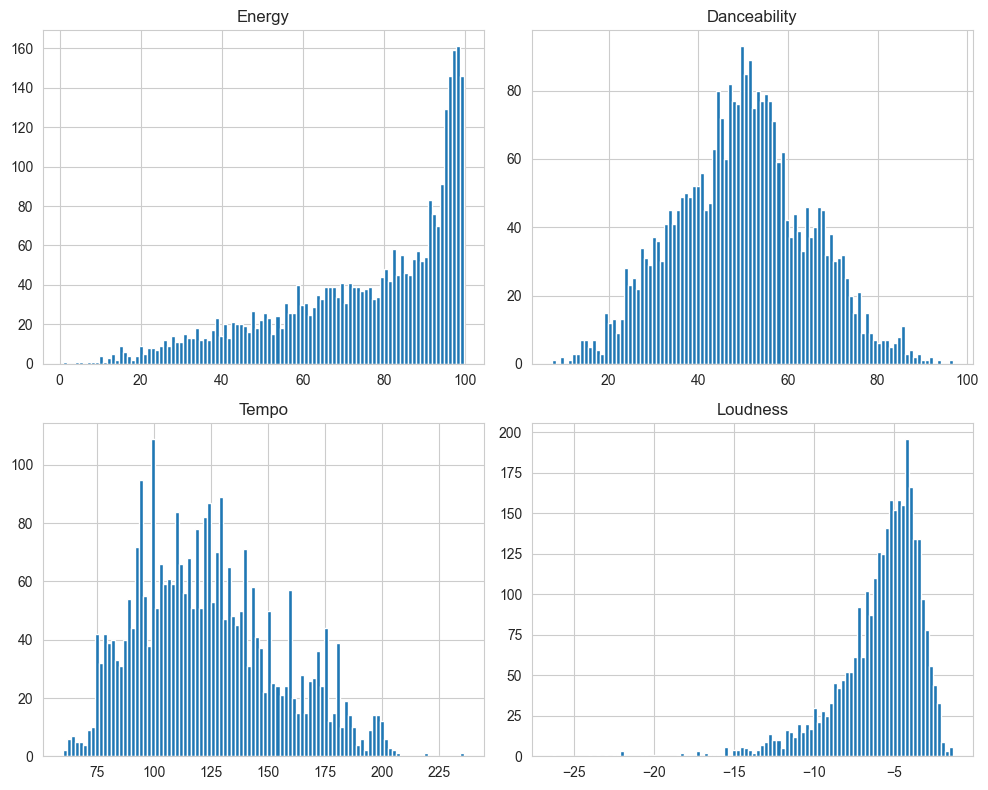

In [5]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

axs[0,0].hist(data["energy"], bins=100)
axs[0,0].set_title("Energy")

axs[0,1].hist(data["danceability"], bins=100)
axs[0,1].set_title("Danceability")

axs[1,0].hist(data["tempo"], bins=100)
axs[1,0].set_title("Tempo")

axs[1,1].hist(data["loudness"], bins=100)
axs[1,1].set_title("Loudness")

plt.tight_layout()
plt.show()

## 2. Estimation

In [6]:
x = data[["danceability", "tempo", "energy", "loudness"]].to_numpy()
n, d = x.shape

# Number of categories
L = 5

# Start params
w_new = np.array([0.2, 0.2, 0.2, 0.2, 0.2])
mu = x[np.random.choice(n, L, replace=False)]
Sigma = np.array([np.cov(x.T) for _ in range(L)])

loglik = 0
max_attempts = 2

# Cycle repeats until it reaches max attempts or until difference between old and new likelihoods becomes very small
for j in range(max_attempts):
    ## E-step
    # Initiate with zeros
    pdf = np.zeros((n,L))

    # For each category we calculate PDF for each song using initial (or updated) parameters
    for l in range(L):
        pdf[:,l] = multivariate_normal(mu[l], Sigma[l]).pdf(x)

    # Calculated weighted PDF per category
    weighted = w_new * pdf

    # By dividing weighed PDF by sum of all weighted PDF's we get probability
    # of each song belonging to each category
    pi = weighted / weighted.sum(axis=1, keepdims=True)

    # Sum all pi values
    pi_sum = pi.sum(axis=0)
    print(pi_sum)

    ## M-step
    # Calculate parameter estimates by using closed form solution
    w_new = pi_sum / n
    mu_new = (pi.T @ x) / pi_sum[:, None]
    Sigma_new = np.zeros((L,d,d))
    for l in range(L):
        diff = x - mu_new[l]
        Sigma_new[l] = (pi[:,l][:,None] * diff).T @ diff / pi_sum[l]

    # Calculate loglikelihood
    loglik_new = np.sum(np.log(weighted.sum(axis=1)))

    print(f"{j} W {w_new}, \nmu {mu_new},\n Sigma \n{Sigma_new},\n loglik {loglik_new}")

    # Check if difference between new and old loglikelihood is not small enough to stop
    if abs(loglik - loglik_new) < 0.01:
        break

    # Update estimated parameters for the next cycle
    loglik = loglik_new
    mu = mu_new
    Sigma = Sigma_new
    w = w_new

[410.41379424 405.88571416 883.74600078 776.09205645 613.86243436]
0 W [0.13282    0.1313546  0.28600194 0.25116248 0.19866098], 
mu [[ 46.74672068 101.22268215  83.49358781  -4.91410176]
 [ 35.33998808 141.55925001  83.08634393  -5.66317858]
 [ 57.88761507 119.49227602  71.2432807   -6.38740325]
 [ 48.86317392 128.04607421  64.46223527  -6.15240429]
 [ 50.7367995  128.51397992  83.34941152  -5.85352384]],
 Sigma 
[[[ 163.00926769   24.50756487  -36.43956229    1.3811388 ]
  [  24.50756487  414.33748929   92.51890791    7.40799655]
  [ -36.43956229   92.51890791  306.53686476   23.96687711]
  [   1.3811388     7.40799655   23.96687711    3.69734117]]

 [[ 135.36570987  -50.14017249    5.57742315    5.72297669]
  [ -50.14017249 1240.08031163  187.25291179   26.90208416]
  [   5.57742315  187.25291179  392.22027566   44.23928441]
  [   5.72297669   26.90208416   44.23928441    8.61654707]]

 [[ 180.87175706  -54.44579097  -64.8447491     1.81531759]
  [ -54.44579097  649.29716546  141.58

## 3. Results
Categories ["danceability", "tempo", "energy", "loudness"]

### 3.1 Estimates of the mean

In [7]:
mu

array([[ 47.03857786, 101.87677973,  85.54087118,  -4.70738331],
       [ 35.20087438, 144.97544156,  82.40340086,  -5.83006308],
       [ 58.73085138, 118.93817549,  69.97505874,  -6.50773755],
       [ 48.50618336, 128.07652707,  63.15667886,  -6.23855951],
       [ 50.56144933, 129.51895678,  84.74636671,  -5.7875076 ]])

### 3.2 Classification into categories

In [8]:
# Set intial values to 0
pdf = np.zeros((n,L))

# For each category calculate PDF for a given song
for l in range(L):
        pdf[:,l] = multivariate_normal(mu[l], Sigma[l]).pdf(x)

# Calculated weighted PDF per category
weighted = w_new * pdf

# By dividing weighed PDF by sum of all weighted PDF's we get probability
# of each song belonging to each category
pi = weighted / weighted.sum(axis=1, keepdims=True)

# Song gets assigned to a category with the highest probability
data["category"] = pi.argmax(axis=1)

# Highest probability is also stored as a separate column
data["category_prob"] = pi.max(axis=1)

In [9]:
data[["name", "artist", "category", "category_prob"]]

,name,artist,category,category_prob
0,A Crisis Of Revelation,Trivium,0,0.796980
1,A Grey so Dark,Trivium,0,0.774646
2,A Gunshot to the Head of Trepidation,Trivium,1,0.481806
3,A Skyline's Severance,Trivium,1,0.661394
4,A View of Burning Empires,Trivium,3,0.667195
...,...,...,...,...
3085,rockstar,Post Malone,3,0.787568
3086,Staring At The Sun (feat. SZA),Post Malone,2,0.391201
3087,Stay,Post Malone,3,0.788626
3088,Take What You Want (feat. Ozzy Osbourne & Trav...,Post Malone,3,0.335510


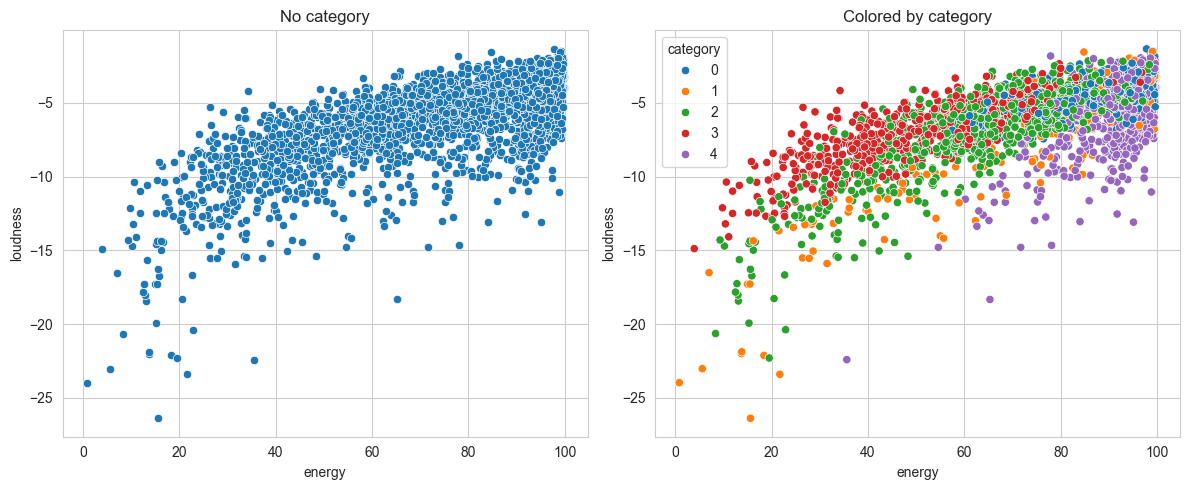

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.scatterplot(
    data=data,
    x="energy",
    y="loudness",
    ax=axes[0]
)
axes[0].set_title("No category")
sns.scatterplot(
    data=data,
    x="energy",
    y="loudness",
    hue="category",
    palette="tab10",
    ax=axes[1]
)
axes[1].set_title("Colored by category")

plt.tight_layout()
plt.show()

### 3.3 Creating playlist

In [11]:
def create_playlist(song_name, artist_name, data):
    song = data[(data["name"] == song_name) & (data["artist"] == artist_name)]
    song_category = song["category"].values[0]
    print(song_category)
    print(song["category_prob"].values[0])
    return data[data["category"] == song_category].nlargest(20, "category_prob")[["name", "artist", "category_prob"]]

In [12]:
create_playlist("Welcome To The Jungle", "Guns 'N Roses", data)

4
0.7643494321381088


,name,artist,category_prob
391,Secular Haze,Ghost,0.995194
1642,Source of Infection,Van Halen,0.974047
1495,Scream of Anger,Europe,0.964245
1596,Guilty of Love,Whitesnake,0.960908
1623,Best of Both Worlds,Van Halen,0.958600
1343,Ride Cowboy Ride,Bon Jovi,0.947299
763,Diary of an Unknown Soldier,Sabaton,0.920014
1500,Wings of Tomorrow,Europe,0.906679
753,Bismarck,Sabaton,0.905100
1606,Spit It Out,Whitesnake,0.901648
